In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300,LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler



#paradigm = P300(resample=48)
#dataset = Lee2019_ERP()

paradigm = LeftRightImagery(resample=64)
dataset = BNCI2014_001()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         #subjects=[1,2,3],
                                         return_epochs=True)

#session = meta['session'][0]
#idc = meta['session'] == session
#epochs = epochs[idc]
#labels = labels[idc]
#meta = meta[idc]
#epochs._data = Scaler(scalings='mean').fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Addin

/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
from hoda.tensorize import stf_tensor

X = epochs.get_data()
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
y = labels

X.shape

/tmp/ipykernel_3613/3071510177.py:3: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   23.2s


(2592, 22, 23, 100)

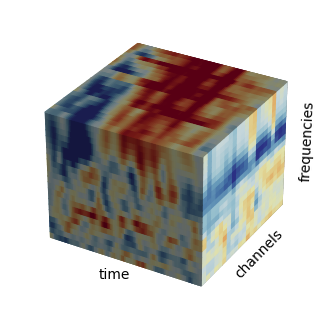

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import CenteredNorm
plt.style.use('default')
def plot_3d_volumetric_heatmap(data):
    """
    Plots a 3D volumetric heatmap using slices with plot_surface.
    
    Parameters:
    data (numpy.ndarray): A 3-dimensional numpy array containing the value at each point.
    """
    x_dim, y_dim, z_dim = data.shape

    # Create figure and 3D axes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Normalize values for color mapping
    #norm = plt.Normalize(data.min(), data.max())
    norm = CenteredNorm()
    
    # Define number of slices and their positions
    slices = 5  # Number of slices along each axis
    x_slices = np.linspace(0, x_dim-1, slices).astype(int)
    y_slices = np.linspace(0, y_dim-1, slices).astype(int)
    z_slices = np.linspace(0, z_dim-1, slices).astype(int)
    
    # Plot slices along the x-axis
    for x in x_slices:
        slice_data = data[x, :, :]
        y_vals, z_vals = np.meshgrid(range(y_dim), range(z_dim), indexing='ij')
        ax.plot_surface(x * np.ones_like(y_vals), y_vals, z_vals, facecolors=plt.cm.RdYlBu_r(norm(slice_data)), rstride=1, cstride=1)
    
    # Plot slices along the y-axis
    for y in y_slices:
        slice_data = data[:, y, :]
        x_vals, z_vals = np.meshgrid(range(x_dim), range(z_dim), indexing='ij')
        ax.plot_surface(x_vals, y * np.ones_like(x_vals), z_vals, facecolors=plt.cm.RdYlBu_r(norm(slice_data)), rstride=1, cstride=1)
    
    # Plot slices along the z-axis
    for z in z_slices:
        slice_data = data[:, :, z]
        x_vals, y_vals = np.meshgrid(range(x_dim), range(y_dim), indexing='ij')
        ax.plot_surface(x_vals, y_vals, z * np.ones_like(x_vals), facecolors=plt.cm.RdYlBu_r(norm(slice_data)), rstride=1, cstride=1)
    
    # Remove color bar, axes, and ticks
    #ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_xlabel('time')
    ax.set_ylabel('channels')
    ax.set_zlabel('frequencies')

    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    
    
    ax.xaxis.labelpad=-18
    ax.yaxis.labelpad=-18
    ax.zaxis.labelpad=-18
    
# Generate example 3D data with different shapes in each dimension
#data = np.random.rand(3, 3, 3)
data = X[y=='right_hand'].mean(axis=0).transpose(2,0,1)[:,:,::-1]
# Plot the 3D volumetric heatmap
plot_3d_volumetric_heatmap(data)
plt.gcf().set_size_inches(4,4)
plt.savefig('mi_tensor.png', bbox_inches='tight', pad_inches=0, transparent=True)

In [31]:
del X
del epochs

In [32]:
from moabb.paradigms import P300,LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler



paradigm = P300(resample=48)
dataset = BI2015b()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         return_epochs=True)


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding m

/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


Adding metadata with 3 columns
116098 matching events found
No baseline correction applied


In [41]:
epochs.drop_channels(['FC5'])

Number of events,116098
Events,NonTarget: 94982Target: 21116
Time range,0.000 – 0.979 s
Baseline,off


In [44]:
img = epochs['Target'].average().get_data()

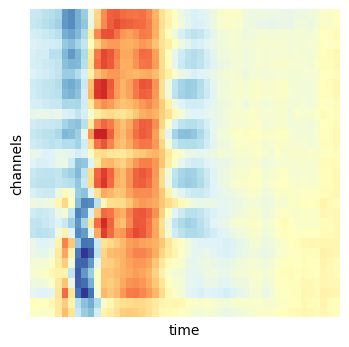

In [52]:
import seaborn as sns

ax = sns.heatmap(img, center=0, cmap='RdYlBu_r', cbar=False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('time')
ax.set_ylabel('channels')
plt.gcf().set_size_inches(4,4)
plt.savefig('erp_tensor.png', bbox_inches='tight', pad_inches=0, transparent=True)